# Week 4 — Final Model: ResNet-50 via Transfer Learning
### The *model* mechanics (you already have the training-loop notebook from Week 3)

Your proposal's final model (Sec 4.1) is **ResNet-50 pretrained on ImageNet**, adapted by transfer learning,
with **ResNet-18** as a lighter, swappable variant. This notebook shows exactly how that model is built and
adapted — head surgery, freezing, fine-tuning, and the one-line backbone swap — plus how to **justify** the
choice with a comparison table.

> **Offline note:** this demo builds the networks with `weights=None` (random init) so it runs anywhere without
> downloading ImageNet weights. On your GPU machine you flip **one flag** (`pretrained=True`) — the parameter
> *counts and structure shown here are identical either way*, which is all that matters for understanding transfer learning.

In [1]:
import torch, torch.nn as nn, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from torchvision import models

SEED = 42; torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_CLASSES = 38                      # your PlantVillage disease classes
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("device:", device, "| classes:", N_CLASSES)

device: cpu | classes: 38


## 1. What transfer learning actually does

A pretrained ResNet already knows generic visual features (edges, textures, shapes) from 1.2M ImageNet images.
We **keep that backbone** and only **replace the final classifier** to output *our* N disease classes:

- **Backbone** = all the residual blocks (the feature extractor) — reuse the pretrained weights.
- **Head** (Sec 4.1) = **Global Average Pool → Dropout → Fully-Connected(N) → Softmax**. (ResNet already ends in a
  global average pool, so "head surgery" means swapping its `fc` layer for `Dropout + Linear(N)`. Softmax is applied
  inside `CrossEntropyLoss`, so we don't add it explicitly.)

**Two-phase recipe:** (1) *freeze* the backbone and train only the new head — fast, needs little data; then
(2) *unfreeze* the top blocks and fine-tune with a **low** learning rate to adapt features to leaves.

In [ ]:
def build_model(backbone="resnet50", n_classes=N_CLASSES, pretrained=True, freeze_backbone=True, dropout=0.3):
    """The Sec 4.1 model, with the backbone swappable by ONE argument."""
    ctor    = {"resnet18": models.resnet18, "resnet50": models.resnet50}[backbone]
    weights = {"resnet18": models.ResNet18_Weights.DEFAULT,
               "resnet50": models.ResNet50_Weights.DEFAULT}[backbone] if pretrained else None
    try:
        net = ctor(weights=weights)                      # loads ImageNet weights when online
    except Exception as e:
        net = ctor(weights=None)                         # offline fallback -> random init
        print(f"[offline] pretrained weights unavailable ({type(e).__name__}); using random init")

    if freeze_backbone:                                  # phase 1: freeze the feature extractor
        for p in net.parameters(): # net.layer4.parameters()
            p.requires_grad = False
    # 99% of weight fixed,

    in_features = net.fc.in_features                     # head surgery: GAP (already in net) -> Dropout -> FC(N)
    net.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, n_classes))
    return net

# a compact baseline for the comparison (Week 3's SimpleCNN)
class SimpleCNN(nn.Module):
    def __init__(self, n, w=32):
        super().__init__()
        blk = lambda i,o: nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(blk(3,w), blk(w,2*w), blk(2*w,4*w), blk(4*w,4*w))
        self.head     = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(4*w, n))
    def forward(self, x): return self.head(self.features(x))

print("build_model() ready — swap backbone with build_model(backbone='resnet18')")

build_model() ready — swap backbone with build_model(backbone='resnet18')


In [3]:
def counts(m):
    total = sum(p.numel() for p in m.parameters())
    train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, train

# build the two backbones (offline: random init; counts are identical to pretrained)
r18 = build_model("resnet18", pretrained=False, freeze_backbone=True)
r50 = build_model("resnet50", pretrained=False, freeze_backbone=True)
scnn = SimpleCNN(N_CLASSES)

# smoke test: head surgery is correct if output is [batch, N_CLASSES]
dummy = torch.randn(4, 3, 224, 224)
print("ResNet-50 output shape:", tuple(r50(dummy).shape), "(expect (4, 38))")

for name, m in [("SimpleCNN (baseline)", scnn), ("ResNet-18 (frozen)", r18), ("ResNet-50 (frozen)", r50)]:
    tot, tr = counts(m)
    print(f"{name:22s} total {tot:12,d} | trainable {tr:10,d} | trainable {100*tr/tot:5.2f}%")

ResNet-50 output shape: (4, 38) (expect (4, 38))
SimpleCNN (baseline)   total      246,438 | trainable    246,438 | trainable 100.00%
ResNet-18 (frozen)     total   11,196,006 | trainable     19,494 | trainable  0.17%
ResNet-50 (frozen)     total   23,585,894 | trainable     77,862 | trainable  0.33%


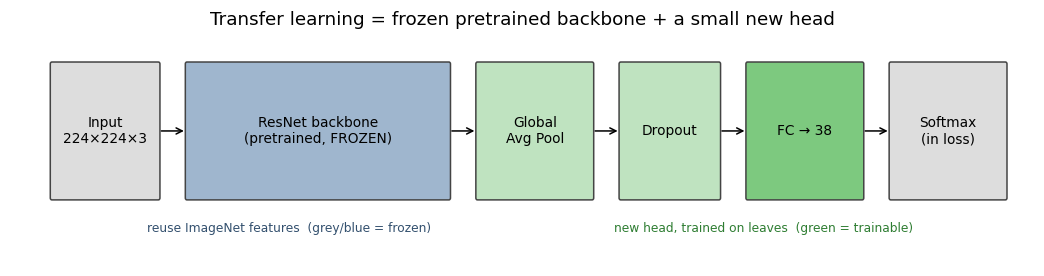

In [4]:
# Schematic: what we keep (frozen backbone) vs what we train (new head)
fig, ax = plt.subplots(figsize=(12, 2.6)); ax.axis("off")
blocks = [("Input\n224×224×3","#DDDDDD",1.3), ("ResNet backbone\n(pretrained, FROZEN)","#9FB6CE",3.2),
          ("Global\nAvg Pool","#BFE3C0",1.4), ("Dropout","#BFE3C0",1.2),
          ("FC → 38","#7DC97F",1.4), ("Softmax\n(in loss)","#DDDDDD",1.4)]
x = 0
for label,color,w in blocks:
    ax.add_patch(mpatches.FancyBboxPatch((x,0), w, 1.4,
                 boxstyle="round,pad=0.02", fc=color, ec="#444"))
    ax.text(x+w/2, 0.7, label, ha="center", va="center", fontsize=9)
    if x>0: ax.annotate("", xy=(x,0.7), xytext=(x-0.35,0.7), arrowprops=dict(arrowstyle="->"))
    x += w + 0.35
ax.text(2.9, -0.35, "reuse ImageNet features  (grey/blue = frozen)", ha="center", fontsize=8, color="#33506e")
ax.text(8.7, -0.35, "new head, trained on leaves  (green = trainable)", ha="center", fontsize=8, color="#2e7d32")
ax.set_xlim(-0.5, x); ax.set_ylim(-0.7, 1.6)
plt.title("Transfer learning = frozen pretrained backbone + a small new head", y=1.05); plt.show()

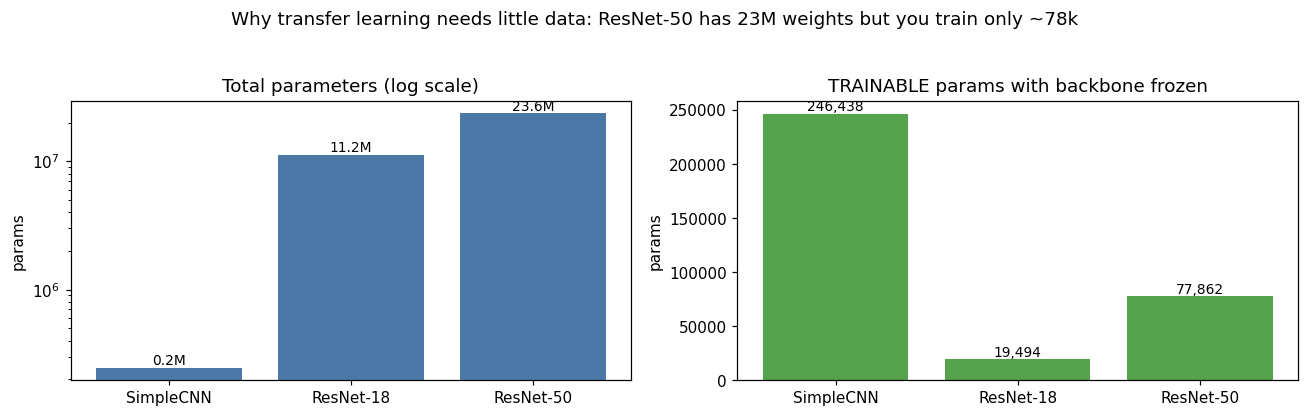

In [5]:
names = ["SimpleCNN", "ResNet-18", "ResNet-50"]
total_p   = [counts(scnn)[0], counts(r18)[0], counts(r50)[0]]
trainable = [counts(scnn)[1], counts(r18)[1], counts(r50)[1]]   # frozen backbone => head only for ResNets

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(names, total_p, color="#4C78A8"); ax[0].set_yscale("log")
ax[0].set_title("Total parameters (log scale)"); ax[0].set_ylabel("params")
for i,v in enumerate(total_p): ax[0].text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

ax[1].bar(names, trainable, color="#54A24B")
ax[1].set_title("TRAINABLE params with backbone frozen"); ax[1].set_ylabel("params")
for i,v in enumerate(trainable): ax[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Why transfer learning needs little data: ResNet-50 has 23M weights but you train only ~78k", y=1.04)
plt.tight_layout(); plt.show()

## 2. The fine-tuning recipe & choosing the backbone

**Phase 1 — feature extraction (freeze):**
```python
model = build_model("resnet50", pretrained=True, freeze_backbone=True).to(device)
opt   = torch.optim.Adam(model.fc.parameters(), lr=1e-3)     # only the head trains
# train a few epochs with the SAME run_epoch/train_model loop from Week 3
```

**Phase 2 — fine-tune (unfreeze top blocks, low LR):**
```python
for p in model.layer4.parameters(): p.requires_grad = True   # unfreeze the last block
opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)  # 10x smaller LR
```

**ResNet-18 vs ResNet-50** — your "swap with one config change" (`build_model("resnet18")`):

| | ResNet-18 | ResNet-50 |
|---|---|---|
| Params | ~11M | ~24M |
| Speed / memory | faster, lighter | heavier |
| Accuracy ceiling | good | usually higher |
| Use for | fast experiments, low-resource deployment | the final reported model |

Same loss, same loop, same metrics — only the backbone string changes. That is what makes the comparison *fair*.

In [6]:
# 3. The JUSTIFICATION table — fill the macro-F1 column from YOUR runs (val set, best epoch)
comparison = pd.DataFrame({
    "model":            ["SimpleCNN (baseline)", "ResNet-18", "ResNet-50"],
    "pretrained":       ["no", "yes", "yes"],
    "total_params":     [f"{p/1e6:.1f}M" for p in total_p],
    "trainable_frozen": [f"{t:,}" for t in trainable],
    "input":            ["224²", "224²", "224²"],
    "role":             ["floor / sanity", "light variant", "final model"],
    "val_macro_F1":     ["  ?  ", "  ?  ", "  ?  "],   # <-- you fill these in
})
print(comparison.to_string(index=False))
print("\nJustification = this table filled with YOUR numbers + reasoning (accuracy is NOT the only column).")

               model pretrained total_params trainable_frozen input           role val_macro_F1
SimpleCNN (baseline)         no         0.2M          246,438  224² floor / sanity          ?  
           ResNet-18        yes        11.2M           19,494  224²  light variant          ?  
           ResNet-50        yes        23.6M           77,862  224²    final model          ?  

Justification = this table filled with YOUR numbers + reasoning (accuracy is NOT the only column).


## Wrap-up & worktime

**You just saw your final model, built:** frozen pretrained backbone + a new `Dropout → FC(38)` head, swappable
between ResNet-18/50 with one argument.

**During worktime:**
1. Build ResNet-50 with `build_model("resnet50", pretrained=True)` (backbone frozen).
2. Train the head a few epochs on your **subset**, using the Week-3 loop — **log val macro-F1**, not just accuracy.
3. Do the same for ResNet-18 and your SimpleCNN baseline.
4. Fill the comparison table. That table + your reasoning **is** your final-model justification.

**Common doubts**
- *"Frozen model won't learn."* → with **pretrained** weights the frozen features are already useful, so the head learns fast. (A frozen *random* net can't — that's why the offline demo here would train unfrozen.)
- *"ResNet-18 beat ResNet-50 on my subset."* → possible on small data; report it honestly, then compare again on the full set. That's exactly why you measure.
- *"Which is the final model?"* → ResNet-50 is the proposed final; ResNet-18 is the documented lighter fallback. Report both.